In [ ]:
   !git clone https://github.com/YashNita/Animal-Sound-Dataset

Cloning into 'Animal-Sound-Dataset'...
remote: Enumerating objects: 887, done.
remote: Total 887 (delta 0), reused 0 (delta 0), pack-reused 887 (from 1)
Receiving objects: 100% (887/887), 100.68 MiB | 17.97 MiB/s, done.
Resolving deltas: 100% (69/69), done.
Updating files: 100% (876/876), done.


In [ ]:
import os
import shutil

# Define the paths
source_dir = "/content/Animal-Sound-Dataset"
destination_dir = "/content/selected_animals"

# Dictionary to map the Turkish folder names to their new English names
class_map = {
    "Aslan": "Lion",
    "Esek": "Donkey",
    "Maymun": "Monkey"
}

# Create the destination directory if it doesn't exist
if os.path.exists(destination_dir):
    shutil.rmtree(destination_dir) # Optional: Remove existing folder to start fresh
os.makedirs(destination_dir)
print(f"Created a fresh directory at: {destination_dir}")

# Loop through the classes, copy them, and rename the folder
for turkish_name, english_name in class_map.items():
    source_path = os.path.join(source_dir, turkish_name)
    destination_path = os.path.join(destination_dir, turkish_name)

    # Check if the source folder exists before copying
    if os.path.exists(source_path):
        # Copy the folder
        shutil.copytree(source_path, destination_path)
        print(f"Copied '{turkish_name}' to '{destination_dir}'")

        # Rename the copied folder to its English name
        final_path = os.path.join(destination_dir, english_name)
        os.rename(destination_path, final_path)
        print(f"Renamed '{turkish_name}' to '{english_name}'")
    else:
        print(f"Warning: Folder '{turkish_name}' not found in the source directory. Skipping.")

print("\nData selection and renaming process complete. Your selected data is now ready.")

Created a fresh directory at: /content/selected_animals
Copied 'Aslan' to '/content/selected_animals'
Renamed 'Aslan' to 'Lion'
Copied 'Esek' to '/content/selected_animals'
Renamed 'Esek' to 'Donkey'
Copied 'Maymun' to '/content/selected_animals'
Renamed 'Maymun' to 'Monkey'

Data selection and renaming process complete. Your selected data is now ready.


In [ ]:
!pip install librosa

In [ ]:
import os
import shutil
import librosa
import librosa.display
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.applications import VGG16

# ======================================================================
# 1. Data Augmentation and Preprocessing
# ======================================================================
def add_noise(data, noise_factor=0.005):
    """Adds random noise to an audio signal."""
    noise = np.random.randn(len(data))
    augmented_data = data + noise_factor * noise
    return augmented_data.astype(type(data[0]))

def stretch_time(data, rate=0.8):
    """Stretches an audio signal in time."""
    return librosa.effects.time_stretch(data, rate=rate)

# Define the path to your selected dataset
data_dir = "/content/selected_animals"

X = []  # To store the spectrograms
y = []  # To store the labels

n_mels = 128
n_fft = 2048
hop_length = 512
max_pad_length = 174

class_labels = {
    "Lion": 0,
    "Donkey": 1,
    "Monkey": 2
}

print("Starting audio preprocessing and augmentation...")

for class_name, label in class_labels.items():
    class_path = os.path.join(data_dir, class_name)

    if not os.path.isdir(class_path):
        print(f"Warning: Directory {class_name} not found. Skipping.")
        continue

    for filename in os.listdir(class_path):
        if filename.endswith(".wav"):
            audio_path = os.path.join(class_path, filename)

            try:
                # Load original audio
                y_orig, sr = librosa.load(audio_path, sr=None)

                # Create a list of audio signals to process (original + augmented)
                audio_signals = [
                    y_orig,
                    add_noise(y_orig),
                    stretch_time(y_orig)
                ]

                # Process each signal
                for y_audio in audio_signals:
                    mel_spectrogram = librosa.feature.melspectrogram(y=y_audio, sr=sr, n_mels=n_mels, n_fft=n_fft, hop_length=hop_length)
                    log_mel_spectrogram = librosa.power_to_db(mel_spectrogram, ref=np.max)

                    # Pad or truncate to a fixed size
                    current_length = log_mel_spectrogram.shape[1]
                    if current_length > max_pad_length:
                        padded_mel_spectrogram = log_mel_spectrogram[:, :max_pad_length]
                    else:
                        padded_mel_spectrogram = np.pad(log_mel_spectrogram, ((0, 0), (0, max_pad_length - current_length)), mode='constant')

                    X.append(padded_mel_spectrogram)
                    y.append(label)

            except Exception as e:
                print(f"Could not process {audio_path}: {e}")

# Convert lists to NumPy arrays
X = np.array(X)
y = np.array(y)

print(f"\nPreprocessed and augmented data shape (X): {X.shape}")
print(f"Preprocessed and augmented labels shape (y): {y.shape}")

# ======================================================================
# 2. Data Splitting and Preparation
# ======================================================================
# Reshape for CNN, adding a channel dimension
# CNN models trained on images typically expect 3 channels (R, G, B)
# So we stack our single-channel spectrogram three times to mimic this
X_rgb = np.stack([X, X, X], axis=-1)
print(f"Reshaped data for VGG16 (3 channels): {X_rgb.shape}")

# One-hot encode the labels
y_one_hot = to_categorical(y)

# Split the data
X_train, X_temp, y_train, y_temp = train_test_split(X_rgb, y_one_hot, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

print("\nData splitting complete.")
print(f"Training data shape: {X_train.shape}")
print(f"Validation data shape: {X_val.shape}")
print(f"Test data shape: {X_test.shape}")

# ======================================================================
# 3. Build and Train the CNN with Transfer Learning
# ======================================================================
# Load the pre-trained VGG16 model (without its final classification layer)
base_model = VGG16(weights='imagenet', include_top=False, input_shape=X_train.shape[1:])

# Freeze the convolutional base to prevent its weights from being updated
base_model.trainable = False

# Create the new model on top of the VGG16 base
x = base_model.output
x = Flatten()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(3, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

# Compile the model
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

# Train the model with Early Stopping
early_stopping = EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)

epochs = 10
batch_size = 32

history = model.fit(X_train, y_train,
                    epochs=epochs,
                    batch_size=batch_size,
                    validation_data=(X_val, y_val),
                    callbacks=[early_stopping])

# ======================================================================
# 4. Evaluate the Model
# ======================================================================
loss, accuracy = model.evaluate(X_test, y_test)
print(f"\nFinal Test Accuracy: {accuracy*100:.2f}%")

Starting audio preprocessing and augmentation...

Preprocessed and augmented data shape (X): (285, 128, 174)
Preprocessed and augmented labels shape (y): (285,)
Reshaped data for VGG16 (3 channels): (285, 128, 174, 3)

Data splitting complete.
Training data shape: (199, 128, 174, 3)
Validation data shape: (43, 128, 174, 3)
Test data shape: (43, 128, 174, 3)
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 174, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 128, 174, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 128, 174, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 64, 87, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 64, 87, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 64, 87, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 32, 43, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 32, 43, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 32, 43, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 32, 43, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 16, 21, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 16, 21, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 16, 21, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 16, 21, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 8, 10, 512)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 8, 10, 512)     │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 8, 10, 512)     │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 8, 10, 512)     │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 4, 5, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 10240)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,310,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,025,923 (61.13 MB)

 Trainable params: 1,311,235 (5.00 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

Epoch 1/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 74s 11s/step - accuracy: 0.5686 - loss: 2.5032 - val_accuracy: 0.7442 - val_loss: 1.5316
Epoch 2/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 82s 11s/step - accuracy: 0.8457 - loss: 0.9659 - val_accuracy: 0.9070 - val_loss: 0.4460
Epoch 3/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 73s 9s/step - accuracy: 0.8838 - loss: 0.5130 - val_accuracy: 0.9767 - val_loss: 0.0919
Epoch 4/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 91s 11s/step - accuracy: 0.9544 - loss: 0.0910 - val_accuracy: 0.9767 - val_loss: 0.0806
Epoch 5/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 72s 11s/step - accuracy: 0.9497 - loss: 0.1603 - val_accuracy: 0.8837 - val_loss: 0.1798
Epoch 6/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 82s 11s/step - accuracy: 0.9260 - loss: 0.2132 - val_accuracy: 0.9070 - val_loss: 0.1957
Epoch 7/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 62s 9s/step - accuracy: 0.9768 - loss: 0.0510 - val_accuracy: 0.9302 - val_loss: 0.2222
Epoch 8/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 94s 11s/step - accuracy: 0.9757 - loss: 0.0376 - val_accuracy: 0.9302 - val_loss: 0.3025
Ep

In [ ]:
# Save the entire model to a .h5 file
model.save('animal_sound_model.h5')

# To use it later, just load it
import tensorflow as tf
loaded_model = tf.keras.models.load_model('animal_sound_model.h5')

In [ ]:
import os
import librosa
import numpy as np

# A dictionary to map the numerical prediction back to the class name
class_names = {0: "Lion", 1: "Donkey", 2: "Monkey"}

def preprocess_audio(file_path):
    """Loads and preprocesses a single audio file."""
    n_mels = 128
    n_fft = 2048
    hop_length = 512
    max_pad_length = 174

    try:
        y_audio, sr = librosa.load(file_path, sr=None)

        # Extract Mel-spectrogram
        mel_spectrogram = librosa.feature.melspectrogram(y=y_audio, sr=sr, n_mels=n_mels, n_fft=n_fft, hop_length=hop_length)
        log_mel_spectrogram = librosa.power_to_db(mel_spectrogram, ref=np.max)

        # Pad or truncate to the fixed size used for training
        current_length = log_mel_spectrogram.shape[1]
        if current_length > max_pad_length:
            padded_mel_spectrogram = log_mel_spectrogram[:, :max_pad_length]
        else:
            padded_mel_spectrogram = np.pad(log_mel_spectrogram, ((0, 0), (0, max_pad_length - current_length)), mode='constant')

        # Reshape for VGG16 (3 channels)
        padded_mel_spectrogram = np.stack([padded_mel_spectrogram, padded_mel_spectrogram, padded_mel_spectrogram], axis=-1)

        # Add a batch dimension
        final_data = np.expand_dims(padded_mel_spectrogram, axis=0)

        return final_data

    except Exception as e:
        print(f"Error processing audio file: {e}")
        return None

In [ ]:
# Example of a new audio file path (you'll need to upload one)
 # Replace with your file path
new_audio_file ='/content/selected_animals/Lion/aslan_12.wav'
# Preprocess the new file
preprocessed_data = preprocess_audio(new_audio_file)

if preprocessed_data is not None:
    # Make the prediction
    predictions = loaded_model.predict(preprocessed_data)

    # Get the predicted class index (the one with the highest probability)
    predicted_index = np.argmax(predictions)

    # Get the class name using your dictionary
    predicted_class = class_names[predicted_index]

    # Print the result
    print(f"\nPredictions: {predictions}")
    print(f"The audio file is predicted to be a: {predicted_class}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 466ms/step

Predictions: [[9.9978203e-01 8.8983193e-16 2.1800997e-04]]
The audio file is predicted to be a: Lion



Generating training history plots...


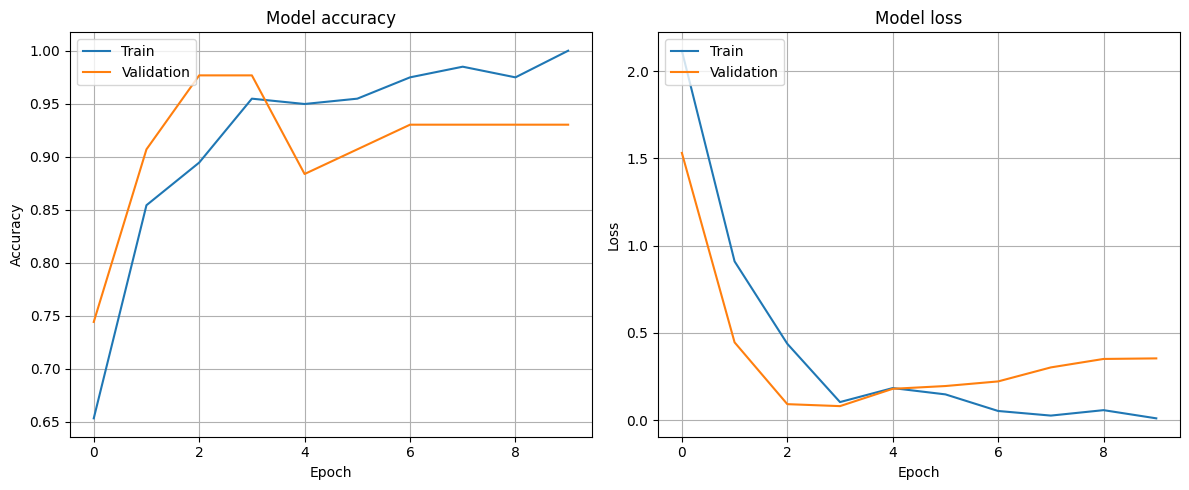


Generating confusion matrix...
2/2 ━━━━━━━━━━━━━━━━━━━━ 11s 3s/step


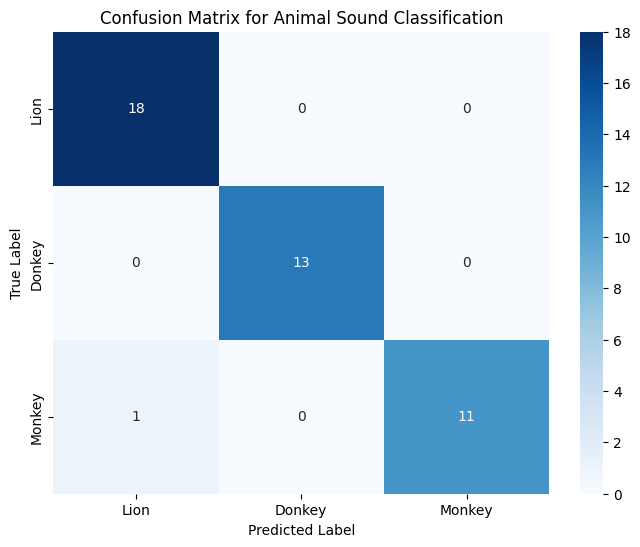


Visualizations complete!


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

# ======================================================================
# 1. Plot Training History (Accuracy and Loss)
# ======================================================================
print("\nGenerating training history plots...")

plt.figure(figsize=(12, 5))

# Plot training & validation accuracy values
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.grid(True)

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.grid(True)

plt.tight_layout()
plt.show()

# ======================================================================
# 2. Confusion Matrix
# ======================================================================
print("\nGenerating confusion matrix...")

# Get predictions for the test set
y_pred_probs = loaded_model.predict(X_test) # Use loaded_model or model if still in scope
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)

# Compute the confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Define class labels for the plot
class_labels_list = ["Lion", "Donkey", "Monkey"]

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels_list, yticklabels=class_labels_list)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Animal Sound Classification')
plt.show()

print("\nVisualizations complete!")

In [ ]:
import os
import shutil

# --- Correct File Paths and Names ---
source_dir = "/content/UrbanSound8K/audio/fold1"
destination_gunshot_dir = "/content/processed_data/gunshots/Gunshot"
destination_no_gunshot_dir = "/content/processed_data/gunshots/No_Gunshot"

# --- Copy Files Based on Their Class ID in the Filename ---
print("Copying files based on class ID...")

# Go through each file in the source directory
for filename in os.listdir(source_dir):
    if filename.endswith(".wav"):
        # The class ID is the second number in the filename
        parts = filename.split('-')
        if len(parts) >= 2:
            try:
                class_id = int(parts[1])

                # If it's a 'gun_shot' (class ID 6), copy it to the Gunshot folder
                if class_id == 6:
                    source_path = os.path.join(source_dir, filename)
                    shutil.copy(source_path, destination_gunshot_dir)
                    print(f"Copied {filename} to Gunshot folder.")

                # If it's a 'siren' (class ID 8), copy it to the No_Gunshot folder
                elif class_id == 8:
                    source_path = os.path.join(source_dir, filename)
                    shutil.copy(source_path, destination_no_gunshot_dir)
                    print(f"Copied {filename} to No_Gunshot folder.")
            except ValueError:
                # In case the class ID is not a number, skip the file
                continue

print("\nFile copying complete. Your dataset is now prepared correctly.")

Copying files based on class ID...


FileNotFoundError: [Errno 2] No such file or directory: '/content/UrbanSound8K/audio/fold1'

In [ ]:
import os
import librosa
import numpy as np

# --- Corrected Preprocessing and Augmentation Functions ---
def add_noise(data, noise_factor=0.005):
    noise = np.random.randn(len(data))
    augmented_data = data + noise_factor * noise
    return augmented_data.astype(type(data[0]))

def stretch_time(data, rate=0.8):
    return librosa.effects.time_stretch(y=data, rate=rate)

def create_spectrogram(y_audio, sr, n_mels=128, n_fft=2048, hop_length=512, max_pad_length=174):
    mel_spectrogram = librosa.feature.melspectrogram(y=y_audio, sr=sr, n_mels=n_mels, n_fft=n_fft, hop_length=hop_length)
    log_mel_spectrogram = librosa.power_to_db(mel_spectrogram, ref=np.max)

    current_length = log_mel_spectrogram.shape[1]
    if current_length > max_pad_length:
        padded_mel_spectrogram = log_mel_spectrogram[:, :max_pad_length]
    else:
        padded_mel_spectrogram = np.pad(log_mel_spectrogram, ((0, 0), (0, max_pad_length - current_length)), mode='constant')

    return padded_mel_spectrogram

# --- Process Datasets ---
X_gunshot = []
y_gunshot = []
gunshot_labels = {"Gunshot": 0, "No_Gunshot": 1}

print("Processing gunshot sounds with augmentation...")
gunshot_data_dir = "/content/processed_data/gunshots"

for class_name, label in gunshot_labels.items():
    class_path = os.path.join(gunshot_data_dir, class_name)
    if os.path.isdir(class_path):
        for filename in os.listdir(class_path):
            audio_path = os.path.join(class_path, filename)

            if os.path.isfile(audio_path) and not filename.startswith('.'):
                try:
                    y_orig, sr = librosa.load(audio_path, sr=None)

                    spectrograms = [
                        create_spectrogram(y_orig, sr),
                        create_spectrogram(add_noise(y_orig), sr),
                        create_spectrogram(stretch_time(y_orig), sr)
                    ]

                    for spec in spectrograms:
                        X_gunshot.append(spec)
                        y_gunshot.append(label)
                except Exception as e:
                    print(f"Skipping file {filename}: {e}")

X_gunshot, y_gunshot = np.array(X_gunshot), np.array(y_gunshot)

print(f"\nGunshot data shape: {X_gunshot.shape}")

In [ ]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

# Reshape data for VGG16 (add 3 channels)
X_gunshot_rgb = np.stack([X_gunshot, X_gunshot, X_gunshot], axis=-1)

# One-hot encode labels
y_gunshot_one_hot = to_categorical(y_gunshot)

# Split Gunshot Data
X_gunshot_train, X_gunshot_test, y_gunshot_train, y_gunshot_test = train_test_split(X_gunshot_rgb, y_gunshot_one_hot, test_size=0.2, random_state=42)
X_gunshot_train, X_gunshot_val, y_gunshot_train, y_gunshot_val = train_test_split(X_gunshot_train, y_gunshot_train, test_size=0.1, random_state=42)

print("All data has been split and prepared for training.")

In [ ]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.applications import VGG16
from tensorflow.keras.callbacks import EarlyStopping

print("Building and training the Gunshot Detection Model...")

# Load the VGG16 base model
base_model_gunshot = VGG16(weights='imagenet', include_top=False, input_shape=X_gunshot_train.shape[1:])
base_model_gunshot.trainable = False

x = base_model_gunshot.output
x = Flatten()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
output_gunshot = Dense(2, activation='softmax')(x) # 2 outputs for 'Gunshot' / 'No_Gunshot'

gunshot_model = Model(inputs=base_model_gunshot.input, outputs=output_gunshot)

gunshot_model.compile(optimizer='adam',
                      loss='categorical_crossentropy',
                      metrics=['accuracy'])

# Train with Early Stopping
early_stopping = EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)
history_gunshot = gunshot_model.fit(X_gunshot_train, y_gunshot_train,
                                  epochs=50,
                                  batch_size=32,
                                  validation_data=(X_gunshot_val, y_gunshot_val),
                                  callbacks=[early_stopping])

print("\nGunshot Detection Model trained.")

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

print("Evaluating the Gunshot Detection Model...")

loss, accuracy = gunshot_model.evaluate(X_gunshot_test, y_gunshot_test)
print(f"\nGunshot Detection Test Accuracy: {accuracy*100:.2f}%")

# Generate and plot confusion matrix
y_pred_gunshot_probs = gunshot_model.predict(X_gunshot_test)
y_pred_gunshot = np.argmax(y_pred_gunshot_probs, axis=1)
y_true_gunshot = np.argmax(y_gunshot_test, axis=1)

cm_gunshot = confusion_matrix(y_true_gunshot, y_pred_gunshot)
gunshot_labels_list = ["Gunshot", "No_Gunshot"]

plt.figure(figsize=(8, 6))
sns.heatmap(cm_gunshot, annot=True, fmt='d', cmap='Blues',
            xticklabels=gunshot_labels_list, yticklabels=gunshot_labels_list)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Gunshot Detection Confusion Matrix')
plt.show()

# The Final Integrated Pipeline
animal_names = {0: "Lion", 1: "Donkey", 2: "Monkey"}
gunshot_status_map = {0: "gunshot detected", 1: "no gunshot detected"}

def final_audio_pipeline(file_path):
    """
    Classifies an audio file first for a gunshot, then for an animal species,
    and returns a single formatted string with confidence.
    """
    try:
        spec, sr = preprocess_audio_file(file_path)
        spec = np.stack([spec, spec, spec], axis=-1)
        spec = np.expand_dims(spec, axis=0)
    except Exception as e:
        return f"Error processing audio file: {e}"

    gunshot_prediction = gunshot_model.predict(spec, verbose=0)
    gunshot_label = np.argmax(gunshot_prediction)
    gunshot_confidence = gunshot_prediction[0][gunshot_label]

    animal_prediction = animal_model.predict(spec, verbose=0)
    animal_label = np.argmax(animal_prediction)

    animal_name = animal_names[animal_label]
    gunshot_status = gunshot_status_map[gunshot_label]

    formatted_string = f"({animal_name}, {gunshot_status}) with a confidence of {gunshot_confidence*100:.2f}%"

    return formatted_string

In [ ]:
from google.colab import files
files.upload()  # upload kaggle.json


Saving kaggle.json to kaggle (1).json


In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Verify Kaggle CLI is available
!pip -q install kaggle
!kaggle --version

Kaggle API 1.7.4.5


In [ ]:
# List matching datasets so you can pick a slug (id)
!kaggle datasets list -s urbansound8k


ref                                            title                                      size  lastUpdated                 downloadCount  voteCount  usabilityRating  
---------------------------------------------  -----------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
chrisfilo/urbansound8k                         UrbanSound8K                         6026232524  2020-02-04 18:37:24.377000          33442        236  0.8235294        
gokulrejith/urban-sound-8k-images              UrbanSound8K Images                   226944585  2021-06-06 11:13:16.807000            314         12  0.9411765        
pranked03/urbansound8k-mel-spectrogram-images  UrbanSound8k Mel Spectrogram Images   940637873  2023-12-14 16:26:39.463000            164         10  0.9411765        
orvile/urban-sound-8k-tabular-form             Urban Sound 8k (Tabular)                1772628  2025-02-23 21:12:53.990000             89         21  0.9411765 

In [ ]:
DATASET_SLUG = "chrisfilo/urbansound8k"
!mkdir -p /content/datasets
%cd /content/datasets
!kaggle datasets download -d "$DATASET_SLUG" -p . --unzip
%cd /content



/content/datasets
Dataset URL: https://www.kaggle.com/datasets/chrisfilo/urbansound8k
License(s): Attribution-NonCommercial 4.0 International (CC BY-NC 4.0)
100% 5.60G/5.61G [01:39<00:00, 29.1MB/s]
100% 5.61G/5.61G [01:39<00:00, 60.7MB/s]
/content


In [ ]:
!ls -R /content/datasets | head -n 100


/content/datasets:
fold1
fold10
fold2
fold3
fold4
fold5
fold6
fold7
fold8
fold9
UrbanSound8K.csv

/content/datasets/fold1:
101415-3-0-2.wav
101415-3-0-3.wav
101415-3-0-8.wav
102106-3-0-0.wav
102305-6-0-0.wav
102842-3-0-1.wav
102842-3-1-0.wav
102842-3-1-5.wav
102842-3-1-6.wav
103074-7-0-0.wav
103074-7-0-1.wav
103074-7-0-2.wav
103074-7-1-0.wav
103074-7-1-1.wav
103074-7-1-2.wav
103074-7-1-3.wav
103074-7-1-4.wav
103074-7-1-5.wav
103074-7-1-6.wav
103074-7-2-0.wav
103074-7-3-0.wav
103074-7-3-1.wav
103074-7-3-2.wav
103074-7-3-3.wav
103074-7-4-0.wav
103074-7-4-1.wav
103074-7-4-2.wav
103074-7-4-3.wav
103074-7-4-4.wav
103074-7-4-5.wav
103074-7-4-6.wav
103258-5-0-0.wav
103258-5-0-10.wav
103258-5-0-11.wav
103258-5-0-12.wav
103258-5-0-13.wav
103258-5-0-14.wav
103258-5-0-15.wav
103258-5-0-16.wav
103258-5-0-17.wav
103258-5-0-18.wav
103258-5-0-19.wav
103258-5-0-1.wav
103258-5-0-2.wav
103258-5-0-3.wav
103258-5-0-4.wav
103258-5-0-5.wav
103258-5-0-6.wav
103258-5-0-7.wav
103258-5-0-8.wav
103258-5-0-9.wav


In [ ]:
import os, glob, hashlib, random, numpy as np, pandas as pd
import librosa, soundfile as sf

# Your layout:
# /content/datasets/
#   ├─ fold1 ... fold10
#   └─ UrbanSound8K.csv
DATA_ROOT = "/content/datasets"
META_CSV  = os.path.join(DATA_ROOT, "UrbanSound8K.csv")
assert os.path.isfile(META_CSV), "UrbanSound8K.csv not found where expected."

# Config
SR = 22050
TARGET_SECS = 4.0
N_MFCC = 40
GUNSHOT_CLASS_ID = 6
CACHE_DIR = "/content/feat_cache_svm"
os.makedirs(CACHE_DIR, exist_ok=True)

# Splits
FOLDS_TRAIN = tuple(range(1,9))  # 1..8
FOLDS_VAL   = (9,)
FOLDS_TEST  = (10,)

meta = pd.read_csv(META_CSV)
print("Rows:", len(meta))
print(meta[['slice_file_name','fold','classID','class']].head())


Rows: 8732
      slice_file_name  fold  classID             class
0    100032-3-0-0.wav     5        3          dog_bark
1  100263-2-0-117.wav     5        2  children_playing
2  100263-2-0-121.wav     5        2  children_playing
3  100263-2-0-126.wav     5        2  children_playing
4  100263-2-0-137.wav     5        2  children_playing


In [ ]:
def row_to_path(row):
    # Your audio is directly under /content/datasets/foldX/filename.wav
    return os.path.join(DATA_ROOT, f"fold{row['fold']}", row['slice_file_name'])

def cache_key(path):
    return os.path.join(CACHE_DIR, hashlib.md5(path.encode()).hexdigest() + ".npy")

def load_audio_fixed(path, sr=SR, secs=TARGET_SECS):
    y, _ = librosa.load(path, sr=sr, mono=True)
    target_len = int(sr * secs)
    if len(y) < target_len:
        y = np.pad(y, (0, target_len - len(y)))
    else:
        y = y[:target_len]
    return y

def extract_features(path):
    """160-D vector: MFCC[40] mean/std + delta MFCC[40] mean/std."""
    y = load_audio_fixed(path, sr=SR, secs=TARGET_SECS)
    mfcc = librosa.feature.mfcc(y=y, sr=SR, n_mfcc=N_MFCC)  # [40, T]
    dmfcc = librosa.feature.delta(mfcc)                      # [40, T]
    feats = []
    for F in (mfcc, dmfcc):
        feats.append(F.mean(axis=1))
        feats.append(F.std(axis=1))
    v = np.concatenate(feats).astype(np.float32)             # 160
    return v

def load_or_compute_features(path):
    cpath = cache_key(path)
    if os.path.exists(cpath):
        return np.load(cpath)
    v = extract_features(path)
    np.save(cpath, v)
    return v


In [ ]:
def make_split(meta_df, folds):
    sub = meta_df[meta_df['fold'].isin(folds)].copy()
    X, y = [], []
    for _, row in sub.iterrows():
        p = row_to_path(row)
        try:
            v = load_or_compute_features(p)
            X.append(v)
            y.append(1 if int(row['classID']) == GUNSHOT_CLASS_ID else 0)
        except Exception as e:
            print("Feature error:", p, e)
    X = np.stack(X) if len(X) else np.zeros((0, 160), dtype=np.float32)
    y = np.array(y, dtype=np.int64)
    return X, y

X_tr, y_tr = make_split(meta, FOLDS_TRAIN)
X_va, y_va = make_split(meta, FOLDS_VAL)
X_te, y_te = make_split(meta, FOLDS_TEST)

print("Shapes:", X_tr.shape, X_va.shape, X_te.shape)
print("Train positives (gunshot):", int(y_tr.sum()), "negatives:", int((y_tr==0).sum()))


Shapes: (7079, 160) (816, 160) (837, 160)
Train positives (gunshot): 311 negatives: 6768


In [ ]:
import numpy as np

def downsample_negatives(X, y, neg_per_pos=3, random_state=42):
    rng = np.random.RandomState(random_state)
    pos_idx = np.where(y == 1)[0]
    neg_idx = np.where(y == 0)[0]
    target_neg = min(len(neg_idx), neg_per_pos * len(pos_idx))
    keep_neg_idx = rng.choice(neg_idx, size=target_neg, replace=False)
    keep_idx = np.concatenate([pos_idx, keep_neg_idx])
    rng.shuffle(keep_idx)
    return X[keep_idx], y[keep_idx]

# try 1:3; you can try 1:2 or 1:4 later
X_tr_bal, y_tr_bal = downsample_negatives(X_tr, y_tr, neg_per_pos=3)
print("Balanced train:", X_tr_bal.shape, "pos:", y_tr_bal.sum(), "neg:", (y_tr_bal==0).sum())


Balanced train: (1244, 160) pos: 311 neg: 933


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

svm_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(kernel='rbf',
                C=2.0,
                gamma='scale',
                class_weight='balanced',   # still helpful
                probability=True,
                random_state=42))
])

model = svm_pipe.fit(X_tr_bal, y_tr_bal)


In [ ]:
import numpy as np
from sklearn.metrics import precision_recall_curve

va_prob = model.predict_proba(X_va)[:, 1]
prec, rec, thr = precision_recall_curve(y_va, va_prob)
f1s = 2 * (prec * rec) / (prec + rec + 1e-9)
best_i = np.argmax(f1s)
best_thr = thr[max(best_i-1, 0)] if best_i < len(thr) else 0.5
print(f"Best val F1={f1s[best_i]:.3f} at threshold={best_thr:.3f}")


Best val F1=0.741 at threshold=0.330


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

def predict_with_threshold(prob, thr):
    return (prob >= thr).astype(int)

# Validation
va_pred = predict_with_threshold(va_prob, best_thr)
print("=== Validation ===")
print(classification_report(y_va, va_pred, target_names=['not_gunshot','gunshot']))
print("ROC-AUC:", roc_auc_score(y_va, va_prob))

# Test
te_prob = model.predict_proba(X_te)[:, 1]
te_pred = predict_with_threshold(te_prob, best_thr)
print("\n=== Test ===")
print(classification_report(y_te, te_pred, target_names=['not_gunshot','gunshot']))
print("ROC-AUC:", roc_auc_score(y_te, te_prob))

print("\nConfusion matrix (test):")
print(confusion_matrix(y_te, te_pred))


=== Validation ===
              precision    recall  f1-score   support

 not_gunshot       1.00      0.97      0.99       785
     gunshot       0.59      0.97      0.73        31

    accuracy                           0.97       816
   macro avg       0.79      0.97      0.86       816
weighted avg       0.98      0.97      0.98       816

ROC-AUC: 0.9920690363673721

=== Test ===
              precision    recall  f1-score   support

 not_gunshot       1.00      0.98      0.99       805
     gunshot       0.60      0.94      0.73        32

    accuracy                           0.97       837
   macro avg       0.80      0.96      0.86       837
weighted avg       0.98      0.97      0.98       837

ROC-AUC: 0.9950698757763975

Confusion matrix (test):
[[785  20]
 [  2  30]]


In [ ]:
import joblib
MODEL_PATH = "/content/svm_gunshot_urbansound8k.joblib"
joblib.dump(model, MODEL_PATH)
print("Saved:", MODEL_PATH)

# Optional: persist to Drive
# from google.colab import drive
# drive.mount('/content/drive')
# !cp -f "$MODEL_PATH" "/content/drive/MyDrive/svm_gunshot_urbansound8k.joblib"


Saved: /content/svm_gunshot_urbansound8k.joblib


In [ ]:
def predict_wav_svm(wav_path, model, thr=0.5):
    # uses the same MFCC+ΔMFCC feature function you already defined
    v = extract_features(wav_path)    # 160-D
    prob = float(model.predict_proba(v.reshape(1, -1))[0, 1])
    return int(prob >= thr), prob

# Example:
# wav = os.path.join(DATA_ROOT, "fold10", os.listdir(os.path.join(DATA_ROOT, "fold10"))[0])
# pred, prob = predict_wav_svm(wav, model, thr=best_thr)
# print("Gunshot?", bool(pred), "prob=", prob)


In [ ]:
!ls /content/datasets/fold10 | head -n 10
# Then set:
# wav_path = "/content/datasets/fold10/<one-of-the-names-above>.wav"



100648-1-0-0.wav
100648-1-1-0.wav
100648-1-2-0.wav
100648-1-3-0.wav
100648-1-4-0.wav
100795-3-0-0.wav
100795-3-1-0.wav
100795-3-1-1.wav
100795-3-1-2.wav
101382-2-0-10.wav


In [ ]:
wav_path = "/content/datasets/fold10/100795-3-1-2.wav"



In [ ]:
def predict_wav_svm_safe(wav_path, model, thr=0.5):
    import os
    if not os.path.isfile(wav_path):
        raise FileNotFoundError(f"Path not found: {wav_path}")
    v = extract_features(wav_path)  # MFCC + ΔMFCC features
    prob = float(model.predict_proba(v.reshape(1, -1))[0, 1])
    pred = int(prob >= thr)
    return pred, prob

# If you tuned best_thr earlier, use it; otherwise just 0.5
pred, prob = predict_wav_svm_safe(wav_path, model, thr=best_thr if 'best_thr' in globals() else 0.5)

if pred == 1:
    print(f"🔴 Gunshot detected! (confidence {prob:.2f})")
else:
    print(f"🟢 No gunshot detected. (confidence {prob:.2f})")


🟢 No gunshot detected. (confidence 0.00)


In [ ]:
import os, pandas as pd

# Load metadata
META_CSV = "/content/datasets/UrbanSound8K.csv"
meta = pd.read_csv(META_CSV)

# Filter only gunshot rows
gun_meta = meta[meta['classID'] == 6]

# Find the first gunshot file that really exists in your folders
wav_path = None
for _, row in gun_meta.iterrows():
    candidate = f"/content/datasets/fold{row['fold']}/{row['slice_file_name']}"
    if os.path.isfile(candidate):
        wav_path = candidate
        print("✅ Found gunshot file:", wav_path)
        break

if wav_path is None:
    raise FileNotFoundError("Could not find any gunshot files in your dataset folders.")


✅ Found gunshot file: /content/datasets/fold1/102305-6-0-0.wav


In [ ]:
pred, prob = predict_wav_svm_safe(
    wav_path,
    model,
    thr=best_thr if 'best_thr' in globals() else 0.5
)

if pred == 1:
    print(f"🔴 Gunshot detected! (confidence {prob:.2f})")
else:
    print(f"🟢 No gunshot detected. (confidence {prob:.2f})")


🔴 Gunshot detected! (confidence 0.92)
